# 조건부 라우팅
Conditional Routing

In [ ]:
# 사용자가 작성한 메시지의 감정 상태가 어떤지 파악해서 답변을 다르게 하는 예제를 작성. 
# 그래프의 흐름: '시작 노드 → 감정 파악 → 부정 답변 | 중립 답변 |긍정 답변 → 종료 노드' .


# import

In [1]:
from dotenv import load_dotenv
load_dotenv()

from typing import Dict, Any, Literal
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import random
from IPython.display import Image, display

# 상태 정의

In [3]:
class EmotionalBotState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 메시지")
    emotion: str = Field(default="", description="분석된 감정")
    response: str = Field(default="", description="최종 응답 메시지")    

# LLM 모델

In [2]:
llm = ChatOpenAI(model='gpt-4o', max_tokens=10)
# 감정분류 결과는 짧은 단어로만 할것이기에 max_tokens = 10

# 노드 정의

## 감정분석 노드

In [4]:
# LLM 기반 감정분석 노드
# 응답은 "positive", "negative", "neutral(기본값)"  3가지중 하나로 답변

def analyze_emotion(state: EmotionalBotState) -> Dict[str, Any]:
    message = state.user_message  # 사용자 전달 메세지
    print(f"🟠 LLM 감정분석중: '{message}'")

    messages = [
        SystemMessage(
            content="당신은 감정 분석 전문가입니다. 사용자의 메시지를 분석하여 'positive', 'negative', 'neutral' 중 하나로 감정을 분류해주세요. 답변은 반드시 하나의 단어만 출력하세요."
        ),
        HumanMessage(content=f"다음 메시지의 감정을 분석해주세요: '{message}'"),
    ]

    response = llm.invoke(messages) 
    emotion = response.content.strip().lower()
    print(f"🟠 모델 응답: {emotion}")

    # 유효성 검사
    if emotion not in ["positive", 'negative', 'neutral']:
        emotion = 'neutral'  # 기본값

    print(f"🟠 LLM 감정 분석 결과: {emotion}")        

    return {"emotion": emotion}   # 상태값 업데이트 -> 이 값에 따라 조건부 라우팅 할거다!
    

## 응답 생성 노드

In [6]:
# 긍정적 응답 생성
def generate_positive_response(state: EmotionalBotState) -> Dict[str, Any]:
    responses = ["정말 좋은 소식이네요!", "기분이 좋으시군요!", "멋지네요!"]
    return {"response": random.choice(responses)}


# 부정적 응답 생성
def generate_negative_response(state: EmotionalBotState) -> Dict[str, Any]:
    responses = [
        "힘든 시간이시군요. 괜찮아요.",
        "마음이 아프시겠어요.",
        "더 좋은 날이 올 거예요.",
    ]
    return {"response": random.choice(responses)}


# 중립적 응답 생성
def generate_neutral_response(state: EmotionalBotState) -> Dict[str, Any]:
    responses = [
        "감사해요! 더 자세히 말씀해주세요.",
        "이해했어요. 다른 도움이 필요하시면 말씀하세요!",
        "흥미로운 주제네요!",
    ]
    return {"response": random.choice(responses)}

# 조건부 라우팅 함수
- 입력: 상태
- 출력: 다음에 실행할 '노드의 이름(str)'

In [9]:
# 조건부 라우팅 함수 - 감정분석결과에 따라 '다음 노드' 결정

def route_by_emotion(
    state: EmotionalBotState
) -> Literal['positive_response', 'negative_response', 'neutral_response']:

    emotion = state.emotion
    print(f'🟣라우팅: {emotion}')

    if emotion == "positive":
        return "positive_response"
    elif emotion == "negative":
        return "negative_response"
    else:
        return "neutral_response"

    # 위 라우팅 함수에서 리턴된 문자열 값에 의해 그래프 내에서 분기될거다

# 그래프 생성

In [10]:
def create_emotion_bot_graph():
    workflow = StateGraph(EmotionalBotState)

    # ⑥ 노드 추가 - 각 처리 단계를 그래프에 등록
    # 노드 추가: add_node() 메서드로 각 처리 함수를 그래프에 등록합니다. 
    # 첫 번째 인자는 노드의 고유 식별자(이름)이고, 두 번째 인자는 실제 실행될 함수입니다. 
    # 이 이름은 나중에 에지를 정의할 때 참조됩니다.
    workflow.add_node("analyze_emotion", analyze_emotion)
    workflow.add_node("positive_response", generate_positive_response)
    workflow.add_node("negative_response", generate_negative_response)
    workflow.add_node("neutral_response", generate_neutral_response)

    # 시작 엣지 설정
    workflow.add_edge(START, "analyze_emotion")

    # 조건부 엣지 설정
    workflow.add_conditional_edges(
        "analyze_emotion", # 출발 노드 이름
        route_by_emotion, # 라우팅 함수
        # 라우팅 함수 결과 -> 분기 목적지 매핑
        {
            "positive_response": "positive_response",
            "negative_response": "negative_response",
            "neutral_response": "neutral_response",
        },
    )

    # 종료 엣지 설정
    workflow.add_edge("positive_response", END)
    workflow.add_edge("negative_response", END)
    workflow.add_edge("neutral_response", END)    


    return workflow.compile()

# 그래프 생성 & 실행

In [12]:
def main():
    print("=== 감정 분석 챗봇 테스트 ===\n")
    app = create_emotion_bot_graph() # 그래프 생성

    test_cases = [
        "오늘 정말 기분이 좋아요!",
        "너무 슬프고 힘들어요...",
        "날씨가 어떤가요?",
    ]

    for i, message in enumerate(test_cases, 1):
        print(f"🟡테스트 {i}: '{message}'")
        state = EmotionalBotState(user_message=message)  # 초기상태
        result = app.invoke(state) # 그래프 실행
        print(f"🟡응답 {i}: {result['response']}\n")


    return app

app = main()

=== 감정 분석 챗봇 테스트 ===

🟡테스트 1: '오늘 정말 기분이 좋아요!'
🟠 LLM 감정분석중: '오늘 정말 기분이 좋아요!'
🟠 모델 응답: positive
🟠 LLM 감정 분석 결과: positive
🟣라우팅: positive
🟡응답 1: 정말 좋은 소식이네요!

🟡테스트 2: '너무 슬프고 힘들어요...'
🟠 LLM 감정분석중: '너무 슬프고 힘들어요...'
🟠 모델 응답: negative
🟠 LLM 감정 분석 결과: negative
🟣라우팅: negative
🟡응답 2: 더 좋은 날이 올 거예요.

🟡테스트 3: '날씨가 어떤가요?'
🟠 LLM 감정분석중: '날씨가 어떤가요?'
🟠 모델 응답: neutral
🟠 LLM 감정 분석 결과: neutral
🟣라우팅: neutral
🟡응답 3: 감사해요! 더 자세히 말씀해주세요.



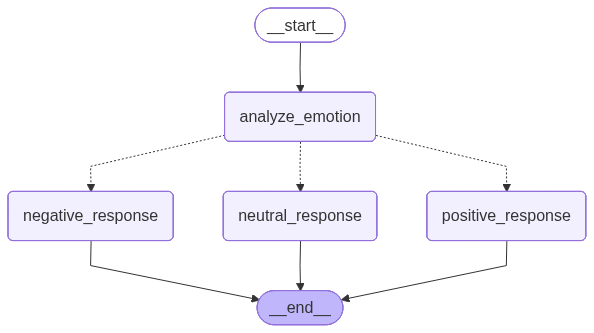

In [13]:
Image(app.get_graph().draw_mermaid_png())